# Fundamentals of Machine Learning — Exercise 1
## First Steps with Jupyter, Pandas, Matplotlib, Seaborn, and Plotly

In this exercise, you will work with a real tabular dataset and practise the basic workflow of data analysis:

> **question → prediction → computation → visualisation → interpretation → verification**

The dataset comes from the Kaggle competition **House Prices: Advanced Regression Techniques**.

### Learning outcomes

By the end of the exercise, you should be able to:

- work with code and Markdown cells in Jupyter Notebook or Google Colab,
- load a CSV file into a Pandas `DataFrame`,
- inspect rows, columns, data types, and missing values,
- select data using `loc` and `iloc`,
- filter rows using logical conditions,
- create meaningful derived variables,
- aggregate data using `groupby`,
- create a plot using Matplotlib, Seaborn, or Plotly,


## How to work in this exercise

This is not a fill-in-the-blanks worksheet. Most code is already available as a starting point. Your task is to:

1. **predict** what a command will do before running it,
2. **modify** code for a new analytical question,
3. **debug** incorrect code,
4. **choose** between possible methods or plots,
5. **interpret** the result in your own words,
6. **verify** that the result is reasonable.

Using an AI assistant for syntax is not a substitute for these decisions. You should be able to explain every line you run and change one part of the analysis when asked.

### Suggested pair-work routine

For selected activities:

- Student A predicts or explains the expected result.
- Student B runs or modifies the code.
- Both compare the result with the prediction.
- Swap roles for the next activity.

## 0. Working with a notebook

A notebook contains two main types of cells:

- **Code cells** execute Python code.
- **Markdown cells** contain formatted text, instructions, equations, and interpretations.

Useful shortcuts:
| Action | Shortcut |
|---|---|
| Run a cell and move to the next one | `Shift + Enter` |
| Run a cell and stay in it | `Ctrl + Enter` |
| Insert a cell above | `A` in command mode |
| Insert a cell below | `B` in command mode |
| Delete a cell | `D`, `D` in command mode |

### Important: notebooks are stateful

Variables remain in memory after a cell has been executed. Therefore, the visible order of cells and the actual execution order may differ.

When results look suspicious, use:

- **Jupyter:** `Kernel → Restart Kernel and Run All Cells`
- **Google Colab:** `Runtime → Restart session and run all`

For this exercise, Google Colab is sufficient. A local Jupyter installation is optional.

### Predict before running

Read both code cells below without executing them.

1. What will the second cell print?
2. What happens if you run the second cell before the first one?
3. What changes if you execute the first cell again with a different value of `exercise_number`?

In [ ]:
course_name = "Fundamentals of Machine Learning"
exercise_number = 1

In [ ]:
print(f"{course_name}: Exercise {exercise_number}")

**Compare the observed result with your prediction.**  

## 1. Imports and display settings

We will use four data-analysis and visualisation libraries:

- **Pandas** — tabular data processing,
- **NumPy** — numerical operations,
- **Matplotlib** — low-level plotting and detailed control,
- **Seaborn** — convenient statistical visualisation built on Matplotlib,
- **Plotly Express** — interactive visualisation.

Plotly is pre-installed in Google Colab. In a local environment, install it with:

```python
%pip install plotly
```

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)

## 2. Dataset

**Source:** [House Prices: Advanced Regression Techniques](https://www.kaggle.com/c/house-prices-advanced-regression-techniques/data)

Each row represents one house sale. The original dataset contains many variables. We will use a smaller subset later.

Important variables include:

| Variable | Meaning |
|---|---|
| `Id` | Row/house identifier |
| `SalePrice` | Sale price in USD |
| `MSSubClass` | Building class code |
| `Neighborhood` | Physical location within Ames |
| `BldgType` | Type of dwelling |
| `HouseStyle` | Style of dwelling |
| `OverallQual` | Overall material and finish quality |
| `OverallCond` | Overall condition rating |
| `YearBuilt` | Original construction year |
| `YrSold` | Year of sale |
| `Heating` | Type of heating |
| `CentralAir` | Central air conditioning (`Y`/`N`) |
| `GrLivArea` | Above-ground living area in square feet |
| `LotArea` | Lot size in square feet |
| `BedroomAbvGr` | Bedrooms above basement level |

> `SalePrice` will later become a **target variable** in a regression task. Here, we only explore and manipulate the data.

In [2]:
DATA_URL = (
    "https://raw.githubusercontent.com/rasvob/"
    "VSB-FEI-Fundamentals-of-Machine-Learning-Exercises/"
    "master/datasets/zsu_cv1_data.csv"
)

df_full = pd.read_csv(DATA_URL)

print("Dataset loaded successfully.")
print(f"Shape: {df_full.shape[0]} rows × {df_full.shape[1]} columns")

Dataset loaded successfully.
Shape: 1460 rows × 81 columns


## 3. First look at the data

A reliable analysis begins by checking what one row represents, which variables are available, and whether the dataset looks as expected.

In [3]:
df_full.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,...,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,...,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,...,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,...,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,...,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


### Activity 1 — Choose the right inspection command

Match each question with a suitable command from the code bank.

**Questions**

A. What are the last ten observations?  
B. What do five reproducibly selected random observations look like?  
C. How many rows and columns are present?  
D. What are the column names?  
E. What are the data types and non-missing counts?

**Code bank**

```python
df_full.info()
df_full.shape
df_full.columns
df_full.tail(10)
df_full.sample(5, random_state=42)
```

Run the commands in an order that you consider useful. Add or rearrange cells as needed.

In [4]:
# Start with the command that you consider most informative.
df_full.sample(5, random_state=42)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
892,893,20,RL,70.0,8414,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Sawyer,Norm,Norm,...,192,0,0,0,0,0,NaN,MnPrv,NaN,0,2,2006,WD,Normal,154500
1105,1106,60,RL,98.0,12256,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NoRidge,Norm,Norm,...,186,32,0,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,325000
413,414,30,RM,56.0,8960,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,OldTown,Artery,Norm,...,0,0,130,0,0,0,NaN,NaN,NaN,0,3,2010,WD,Normal,115000
522,523,50,RM,50.0,5000,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,BrkSide,Feedr,Norm,...,0,24,36,0,0,0,NaN,NaN,NaN,0,10,2006,WD,Normal,159000
1036,1037,20,RL,89.0,12898,Pave,NaN,IR1,HLS,AllPub,Inside,Gtl,Timber,Norm,Norm,...,228,0,0,0,0,0,NaN,NaN,NaN,0,9,2009,WD,Normal,315500


### Stop and explain

Discuss or write short answers:

1. What does one row represent?
2. Which column is the likely target variable for a future regression model?
3. Why should `Id` normally not be used as a numerical predictor?
4. Which inspection command would you run first on an unfamiliar dataset, and why?

## 4. Data types and missing values

In [5]:
df_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

### Activity 2 — Numeric does not always mean quantitative

The following variables are all stored as numbers:

- `Id`
- `MSSubClass`
- `OverallQual`
- `GrLivArea`

Assign each variable one of these roles:

- **identifier**
- **categorical code**
- **ordinal variable**
- **continuous measurement**

Then answer: what could go wrong if `MSSubClass` were interpreted as an ordinary continuous measurement?

In [3]:
df_full[["Id", "MSSubClass", "OverallQual", "GrLivArea"]]

,Id,MSSubClass,OverallQual,GrLivArea
0,1,60,7,1710
1,2,20,6,1262
2,3,60,7,1786
3,4,70,7,1717
4,5,60,8,2198
...,...,...,...,...
1455,1456,60,6,1647
1456,1457,20,6,2073
1457,1458,70,7,2340
1458,1459,20,5,1078


### Missing values: compare two approaches

First, predict which output will be more useful for an analyst.

In [6]:
# Approach A
df_full.isna()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,True,True,False,False,False,False,False,False
1,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,True,True,False,False,False,False,False,False
2,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,True,True,False,False,False,False,False,False
3,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,True,True,False,False,False,False,False,False
4,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,True,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,True,True,False,False,False,False,False,False
1456,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False
1457,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
1458,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,True,True,False,False,False,False,False,False


In [7]:
# Approach B
missing_values = df_full.isna().sum().sort_values(ascending=False)
missing_values[missing_values > 0].head(15)

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageQual,81
GarageFinish,81
GarageType,81


### Explain the difference

Why is Approach B usually more useful? What information is still missing if we only report the number of missing values and not their percentage?

### Modify the analysis

Extend Approach B so that the output contains both:

- the number of missing values,
- the percentage of missing values.

Do not ask an AI assistant for a complete solution immediately. First decide which denominator is required.

Hint: what is the output of `len(df_full)`

In [ ]:
missing_summary = pd.DataFrame({
    "missing_count": df_full.isna().sum(),
    # Add a second column named "missing_percent".

})

missing_summary = missing_summary.loc[
    missing_summary["missing_count"] > 0
].sort_values("missing_count", ascending=False)

missing_summary.head(15)

,missing_count
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageType,81
GarageYrBlt,81
GarageFinish,81


## 5. Create a smaller working DataFrame

In [5]:
selected_columns = [
    "Id",
    "SalePrice",
    "MSSubClass",
    "Neighborhood",
    "BldgType",
    "HouseStyle",
    "OverallQual",
    "OverallCond",
    "YearBuilt",
    "YrSold",
    "Heating",
    "CentralAir",
    "GrLivArea",
    "LotArea",
    "BedroomAbvGr",
]

df = df_full.loc[:, selected_columns].copy()
df.head()

,Id,SalePrice,MSSubClass,Neighborhood,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YrSold,Heating,CentralAir,GrLivArea,LotArea,BedroomAbvGr
0,1,208500,60,CollgCr,1Fam,2Story,7,5,2003,2008,GasA,Y,1710,8450,3
1,2,181500,20,Veenker,1Fam,1Story,6,8,1976,2007,GasA,Y,1262,9600,3
2,3,223500,60,CollgCr,1Fam,2Story,7,5,2001,2008,GasA,Y,1786,11250,3
3,4,140000,70,Crawfor,1Fam,2Story,7,5,1915,2006,GasA,Y,1717,9550,3
4,5,250000,60,NoRidge,1Fam,2Story,8,5,2000,2008,GasA,Y,2198,14260,4


### What we say by using : in `df_full[:, selected_columns]`

### Why `.copy()`?

Predict what the intention of `.copy()` is. You do not need to memorise all technical details yet; explain why an independent working table may be safer than repeatedly modifying the original data.

## 6. Selecting rows and columns: `iloc` and `loc`

- `iloc` selects by **integer position**.
- `loc` selects by **labels** and can also use logical conditions.

### Activity 3 — Predict the shape

Without running the cells, predict the number of rows and columns in each result.

In [6]:
selection_a = df.iloc[3:10, 2:6]
selection_a

,MSSubClass,Neighborhood,BldgType,HouseStyle
3,70,Crawfor,1Fam,2Story
4,60,NoRidge,1Fam,2Story
5,50,Mitchel,1Fam,1.5Fin
6,20,Somerst,1Fam,1Story
7,60,NWAmes,1Fam,2Story
8,50,OldTown,1Fam,1.5Fin
9,190,BrkSide,2fmCon,1.5Unf


In [7]:
selection_b = df.loc[3:10, "MSSubClass":"OverallCond"]
selection_b

,MSSubClass,Neighborhood,BldgType,HouseStyle,OverallQual,OverallCond
3,70,Crawfor,1Fam,2Story,7,5
4,60,NoRidge,1Fam,2Story,8,5
5,50,Mitchel,1Fam,1.5Fin,5,5
6,20,Somerst,1Fam,1Story,8,5
7,60,NWAmes,1Fam,2Story,7,6
8,50,OldTown,1Fam,1.5Fin,7,5
9,190,BrkSide,2fmCon,1.5Unf,5,6
10,20,Sawyer,1Fam,1Story,5,5


Now compare the actual shapes:

```python
selection_a.shape
selection_b.shape
```

Explain why the number of selected rows differs. Also explain why selecting columns by name may be safer than relying on their current positions.

### Debugging activity

The intention is to select the `LotArea` column for rows with labels 3 to 9. The code below does not express that intention correctly.

1. Identify the problem.
2. Correct it using `loc`.
3. Write an alternative using `iloc`.

In [8]:
# Incorrect for the stated intention:
wrong_selection = df.iloc[3:9, "LotArea"]

ValueError: Location based indexing can only have [integer, integer slice (START point is INCLUDED, END point is EXCLUDED), listlike of integers, boolean array] types

## 7. Filtering with logical conditions

In [ ]:
# Worked example: houses built in 2000 or later
houses_2000_or_later = df.loc[df["YearBuilt"] >= 2000]
houses_2000_or_later.head()

### Activity 4 — Debug three filters

Each filter below contains a common error. Correct the expressions and explain the error in words.

The intended subsets are:

1. houses cheaper than 180,000 USD **and** with at least two bedrooms,
2. houses with the `2Story` style **or** central air conditioning,
3. houses that do **not** use `GasA` heating.

In [ ]:
# Filter 1: incorrect use of Python's "and"
# affordable_family_houses = df.loc[
#     (df["SalePrice"] < 180_000) and (df["BedroomAbvGr"] >= 2)
# ]

# Filter 2: missing parentheses
# two_storey_or_air = df.loc[
#     df["HouseStyle"] == "2Story" | df["CentralAir"] == "Y"
# ]

# Filter 3: wrong comparison operator for "not equal"
# houses_without_gasa = df.loc[df["Heating"] =! "GasA"]

### Verification challenge

After correcting the filters, verify each result using a different method. Examples:

- inspect the minimum or maximum of a relevant column,
- use `value_counts()`,
- use `query()` as an alternative,
- check whether an invalid value is present using `.any()`.

Simply displaying the first five rows is not sufficient verification.

## 8. Creating meaningful variables

A derived variable should represent a clearly defined concept and should use information from the correct point in time.

### Activity 5 — Find the conceptual bug

The following expression looks syntactically correct:

```python
df["HouseAge"] = 2026 - df["YearBuilt"]
```

Why is this a poor definition for analysing historical sales? Choose the more meaningful representation and create `HouseAgeAtSale`.

In [9]:
df["HouseAgeAtSale"] = df["YrSold"] - df["YearBuilt"]

df.loc[:, ["YearBuilt", "YrSold", "HouseAgeAtSale"]].head()

,YearBuilt,YrSold,HouseAgeAtSale
0,2003,2008,5
1,1976,2007,31
2,2001,2008,7
3,1915,2006,91
4,2000,2008,8


### Verify the new variable

Check:

- its minimum and maximum,
- whether any values are negative,
- one row with the maximum age.

If you find an unexpected value, do not delete it automatically. First investigate it.

In [ ]:
df["HouseAgeAtSale"].describe()

### Activity 6 — From text to Boolean

Create a Boolean variable `HasCentralAir` from `CentralAir`.

Before writing code, answer:

- Which original value should map to `True`?
- How many distinct original values are present?
- How will you verify that the conversion is correct?

A concise starting expression is shown below. Complete and verify it.

In [10]:
df["CentralAir"].value_counts(dropna=False)

# Modify the comparison:
df["HasCentralAir"] = df["CentralAir"].eq("...")

pd.crosstab(df["CentralAir"], df["HasCentralAir"], dropna=False)

HasCentralAir,False
CentralAir,
N,95
Y,1365


## 9. Aggregation with `groupby`

Aggregation changes the unit of analysis. Instead of one row per house, the result may contain one row per building type, neighborhood, or heating category.

In [ ]:
df["Heating"].value_counts()

### Activity 7 — Choose a robust summary

Suppose we want to compare sale prices among building types.

Discuss:

1. Would the mean or median be more robust to very expensive houses?
2. Why is the group size necessary for interpretation?
3. Is comparing prices enough, or might living area also matter?

Complete the summary below by choosing appropriate aggregation functions.

In [11]:
building_type_summary = (
    df.groupby("BldgType", observed=True)
      .agg(
          NumberOfHouses=("Id", "count"),
          TypicalPrice=("SalePrice", "..."),   # choose mean or median
          TypicalArea=("GrLivArea", "..."),    # choose and justify
      )
      .sort_values("TypicalPrice", ascending=False)
)

building_type_summary

AttributeError: 'SeriesGroupBy' object has no attribute '...'

### Interpretation checkpoint

Which building type has the highest typical price? Does this result prove that the building type itself causes the price difference? Name at least one possible confounding variable. 

**A confounding variable is a third factor that is linked to both things you are comparing. It can make it look as if A causes B, when the real (or bigger) reason is that third factor.**

# 10. Visualisation

A graph is not the final result. Every graph should answer a question and should be followed by interpretation and verification.

We will compare:

1. **Matplotlib** — detailed control,
2. **Seaborn** — concise statistical graphics,
3. **Plotly Express** — interactive graphics.

## 10.1 Matplotlib — build and inspect a static plot

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df["SalePrice"], bins=30, edgecolor="black")
plt.title("Distribution of house sale prices")
plt.xlabel("Sale price [USD]")
plt.ylabel("Number of houses")
plt.tight_layout()
plt.show()

### Activity 8 — Make two deliberate choices

Modify the histogram in two ways:

1. compare at least two different values of `bins`,
2. decide whether the x-axis would be easier to read in USD or thousands of USD.

Do not choose a setting only because it “looks nice”. Explain how the choice changes what the reader can see.

In [ ]:
# Modify the number of bins and, optionally, transform the displayed unit.
plot_values = df["SalePrice"]

plt.figure(figsize=(8, 5))
plt.hist(plot_values, bins=30, edgecolor="black")
plt.title("Distribution of house sale prices")
plt.xlabel("Sale price [USD]")
plt.ylabel("Number of houses")
plt.tight_layout()
plt.show()

## 10.2 Seaborn — choose a plot for a question

**Question:** How does sale price vary with living area, and does the pattern appear different for houses with and without central air?

Before running the code, answer what would you expect as a result.

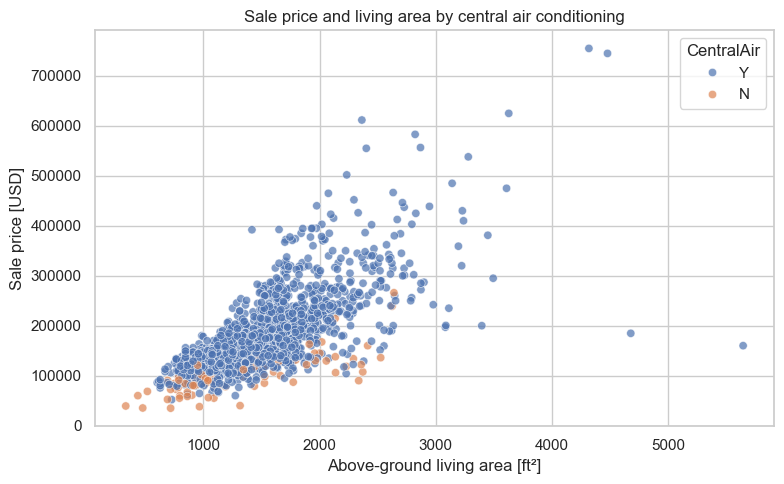

In [12]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="GrLivArea",
    y="SalePrice",
    hue="CentralAir",
    alpha=0.7,
)

plt.title("Sale price and living area by central air conditioning")
plt.xlabel("Above-ground living area [ft²]")
plt.ylabel("Sale price [USD]")
plt.tight_layout()
plt.show()

### Interpretation checkpoint
Write three sentences:

1. describe the main pattern,
2. identify unusual observations or region.


## 10.3 Plotly Express — investigate individual observations

Interactive plots are useful when hovering over individual observations changes what you can learn from the figure.

In [14]:
fig = px.scatter(
    df,
    x="GrLivArea",
    y="SalePrice",
    color="CentralAir",
    hover_data=[
        "Id",
        "Neighborhood",
        "OverallQual",
        "YearBuilt",
        "BldgType",
    ],
    title="Interactive view of sale price and living area",
    labels={
        "GrLivArea": "Above-ground living area [ft²]",
        "SalePrice": "Sale price [USD]",
        "CentralAir": "Central air",
    },
    opacity=0.7,
)

fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

### Activity 9 — Use interactivity for a purpose

Use zooming and hover information to select one unusual house.

Record:

- its `Id`,
- why it appears unusual,
- two other variables that may help explain its position.

Then modify `hover_data` by adding one variable that supports your investigation and removing one that does not.

# End-of-lab self-check
You do not submit this exercise for points. Before finishing, check that you can:

- [ ] explain the difference between `loc` and `iloc`,
- [ ] use logical operations in pandas,
- [ ] distinguish an identifier from a meaningful numerical feature,
- [ ] filter and select values,
- [ ] use min, max functions,
- [ ] create a plot in matplotlib, seaborn and plotly,
- [ ] approach missing values.

These skills will be used later in the semester project.